In [1]:
# libraries 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
import json
from pandas import json_normalize
import zipfile
import matplotlib.pyplot as plt
import seaborn as sns
import glob

In [2]:
import hashlib

def encrypt_id(val):
    return int(hashlib.sha256(str(val).encode()).hexdigest(), 16) % (10**9)

def aligning_data(dataframe, base_id):
    dataframe.columns = dataframe.columns.str.lower()

    for col in dataframe.columns:
        if "id" in col:
            dataframe.rename(columns={col: "id"}, inplace=True)
            dataframe["id"] = dataframe["id"].astype(int)
            dataframe["id"] = dataframe["id"].apply(encrypt_id)
        elif "time" in col:
            dataframe.rename(columns={col: "time"}, inplace=True)
        elif "value" in col or "hr" in col or "heartrate" in col:
            dataframe.rename(columns={col: "value"}, inplace=True)
        else:
            dataframe.drop(columns=[col], axis=1, inplace=True)

    if "id" not in dataframe.columns:
        dataframe["id"] = base_id
        dataframe["id"] = dataframe["id"].apply(encrypt_id)

    dataframe["time"] = pd.to_datetime(dataframe["time"])

    # dropping na values and inf values - for now only on value column
    dataframe = dataframe.dropna(subset=["value"])
    dataframe = dataframe[np.isfinite(dataframe["value"])]

    # dataframe = dataframe[dataframe["value"] != 0]
    # dataframe = dataframe[dataframe["value"] != np.inf]
    dataframe["value"] = dataframe["value"].astype(int)

    dataframe.drop_duplicates(inplace=True)

    return dataframe

## Importing Data

In [3]:
## 1 ****************************************************************** Importing FITABASE DATA ******************************************************************
# importing Fitabase Dta first experiment data
heart_rate_fitabase_first = pd.read_csv(r"csv_data/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/heartrate_seconds_merged.csv")
# importing Fitabase Dta Second experiment data
heart_rate_fitabase_second = pd.read_csv(r"csv_data/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/heartrate_seconds_merged.csv")

## 2 ****************************************************************** One per user ******************************************************************
heart_rate_user_1 = pd.read_csv(r"csv_data/Experiment_one_per_user/1-s2.0-S2352340917305577-mmc2.csv")
heart_rate_user_2 = pd.read_csv(r"csv_data/Experiment_one_per_user/1-s2.0-S2352340917305577-mmc4.csv")

## 3 ****************************************************************** AOU******************************************************************
heart_rate_AOU = pd.read_csv(r"csv_data/first_10_person_id.txt")

## 4 ****************************************************************** april 23 and 24 ******************************************************************
path = f"csv_data/heart_rate_2023-04-23.json"
path1 = f"csv_data/heart_rate_2023-04-24.json"
april_all_dfs = []

with open(path, "r") as f:
    raw = json.load(f)
    df = json_normalize(raw)
    df['participant'] = f"1"
april_all_dfs.append(df)

with open(path1, "r") as f:
    raw = json.load(f)
    df = json_normalize(raw)
    df['participant'] = f"2"
april_all_dfs.append(df)
# concatenating all the dataframes
heart_rate_april = pd.concat(april_all_dfs)

## 5 ****************************************************************** one person ****************************************************************** 
heart_rate_one_person = pd.read_csv(r"csv_data/Heart_rate_minute_more than one person.csv")

In [4]:
# 6 ****************************************************************** P files - parquet files ******************************************************************
parquet_files = glob.glob("parquet_data/*.parquet")
parque_file_1 = pd.read_parquet("parquet_data/p01.parquet")
parque_file_2 = pd.read_parquet("parquet_data/p02.parquet")
parque_file_3 = pd.read_parquet("parquet_data/p03.parquet")
parque_file_4 = pd.read_parquet("parquet_data/p04.parquet")
parque_file_5 = pd.read_parquet("parquet_data/p05.parquet")
parque_file_6 = pd.read_parquet("parquet_data/p06.parquet")
parque_file_7 = pd.read_parquet("parquet_data/p07.parquet")
parque_file_8 = pd.read_parquet("parquet_data/p08.parquet")
parque_file_9 = pd.read_parquet("parquet_data/p09.parquet")
parque_file_10 = pd.read_parquet("parquet_data/p10.parquet")
parque_file_11 = pd.read_parquet("parquet_data/p11.parquet")
parque_file_12 = pd.read_parquet("parquet_data/p12.parquet")
parque_file_13 = pd.read_parquet("parquet_data/p13.parquet")
parque_file_14 = pd.read_parquet("parquet_data/p14.parquet")
parque_file_15 = pd.read_parquet("parquet_data/p15.parquet")
parque_file_16 = pd.read_parquet("parquet_data/p16.parquet")
parque_file_concat = pd.concat([parque_file_1,
                                 parque_file_2,
                                   parque_file_3,
                                     parque_file_4, 
                                      parque_file_5,
                                        parque_file_6,
                                          parque_file_7, 
                                           parque_file_8, 
                                            parque_file_9, 
                                            parque_file_10, 
                                             parque_file_11, 
                                              parque_file_12, 
                                               parque_file_13, 
                                                parque_file_14, 
                                                 parque_file_15, 
                                                  parque_file_16])

In [5]:
# 7 ****************************************************************** wearable_hr 88 users ******************************************************************
wearable_parquet = pd.read_parquet("parquet_data/df_wearable_hr.parquet")

## CLEANING AND ALIGNING

In [6]:
group = [heart_rate_fitabase_first, heart_rate_fitabase_second, heart_rate_user_1, heart_rate_user_2, heart_rate_AOU, heart_rate_april, heart_rate_one_person, parque_file_concat, wearable_parquet]

number = 3
group[number]


,date_time,hr,steps,gsr,calories,temp
0,2016-08-15 00:00:00,122.0,0,0.000052,7.5,77.9
1,2016-08-15 00:01:00,135.0,0,0.000051,8.2,77.9
2,2016-08-15 00:02:00,111.0,0,0.000052,6.2,77.9
3,2016-08-15 00:03:00,109.0,0,0.000053,5.6,77.0
4,2016-08-15 00:04:00,126.0,0,0.000053,9.0,77.0
...,...,...,...,...,...,...
73435,2016-10-04 23:55:00,85.0,0,0.000056,1.9,86.9
73436,2016-10-04 23:56:00,83.0,0,0.000056,1.8,86.9
73437,2016-10-04 23:57:00,85.0,0,0.000057,1.9,86.9
73438,2016-10-04 23:58:00,93.0,0,0.000056,3.1,86.9


In [7]:
heart_rate_AOU["person_id"].value_counts()

person_id
2716456    10982
Name: count, dtype: int64

In [8]:
# Calling function to clean data
heart_rate_fitabase_first_ca = aligning_data(group[0], base_id=1)
heart_rate_fitabase_second_ca = aligning_data(group[1], base_id=2)
heart_rate_user_1_ca = aligning_data(group[2], base_id=3)
heart_rate_user_2_ca = aligning_data(group[3], base_id=4)   
heart_rate_AOU_ca = aligning_data(group[4], base_id=5)
heart_rate_april_ca = aligning_data(group[5], base_id=6)
heart_rate_one_person_ca = aligning_data(group[6], base_id=7)
parque_file_concat_ca = aligning_data(group[7], base_id=8)
wearable_parquet_ca = aligning_data(group[8], base_id=9)

/tmp/ipykernel_8095/1817643381.py:25: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dataframe["time"] = pd.to_datetime(dataframe["time"])


In [9]:
all_data_frames = pd.concat([heart_rate_fitabase_first_ca,
                              heart_rate_fitabase_second_ca,
                                heart_rate_user_1_ca,
                                  heart_rate_user_2_ca,
                                    heart_rate_AOU_ca,
                                      heart_rate_april_ca, 
                                        heart_rate_one_person_ca,
                                          parque_file_concat_ca, 
                                          wearable_parquet_ca])

all_data_frames.reset_index(drop=True, inplace=True)
all_data_frames.info()

# The entire dataframe has 38,062,855 mln entires


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38062856 entries, 0 to 38062855
Data columns (total 3 columns):
 #   Column  Dtype         
---  ------  -----         
 0   id      int64         
 1   time    datetime64[ns]
 2   value   int64         
dtypes: datetime64[ns](1), int64(2)
memory usage: 871.2 MB


## Checking Dataframe

In [10]:
all_data_frames.head()

,id,time,value
0,744157216,2016-04-01 07:54:00,93
1,744157216,2016-04-01 07:54:05,91
2,744157216,2016-04-01 07:54:10,96
3,744157216,2016-04-01 07:54:15,98
4,744157216,2016-04-01 07:54:20,100


In [11]:
len(all_data_frames["id"].unique()) ## --> more than 100 users
all_data_frames["id"].unique()

array([744157216, 213682059, 810487652, 948726728, 814281087, 671420222,
       958370773, 688802394, 356486766, 317586544, 389786680, 528653633,
        54766148, 379841473, 139783589, 205321678, 468157322, 792186960,
       507514449, 331159861, 658922315, 402595305, 172823453,  15414403,
       619831459, 143503287, 449103317, 131365048, 158240536, 705779832,
       946861665,  64447963, 507872473, 101685731, 160791370, 662158183,
       158906923, 647403587, 820123913, 635087248, 722538966, 692795355,
       970134377, 940403402, 511046831, 865638746, 939925321, 192943704,
       558171124, 430344975, 366514027, 394040468, 675065327, 245649747,
       559940713,  41231653, 640619632, 877176825, 203005699, 358724825,
        53089353, 386133306, 312693974, 256979052, 267464972, 667121687,
        28845937, 137128223, 165498091, 818513834, 498335837, 851943209,
       902444142, 382872252, 646638694, 411495508, 279513558, 789167964,
       722771657, 906263324, 977125002, 376670236, 

In [12]:
all_data_frames.isna().sum() ## no nas or missing values now
all_data_frames.dtypes

id                int64
time     datetime64[ns]
value             int64
dtype: object

In [13]:
all_data_frames.to_parquet("parquet_data/all_data_frames.parquet")

## EDA

In [14]:
# ## Splitting the data
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import LabelEncoder

# training_data, test_data = train_test_split(all_data_frames, test_size=0.3, random_state=42)


## APPENDIX

In [15]:
# # ## 6****************************************************************** All included ******************************************************************

# all_dfs = []
# for i in range(1, 17):
#     path = f"csv_data/Fitbit_heart_rate_all/p{str(i).zfill(2)}/fitbit/heart_rate.json"
#     try:
#         with open(path, "r") as f:
#             raw = json.load(f)

#         # Flatten the structure
#         df = json_normalize(raw)
#         df['participant'] = f"p{str(i).zfill(2)}"
#         all_dfs.append(df)

#     except Exception as e:
#         print(f"❌ Failed to load {path}: {e}")

# # Concatenate all the dataframes
# heart_rate_all_json = pd.concat(all_dfs)

# 7 ****************************************************************** Wearable Activity data tracker ******************************************************************
# import sqlite3

# conn = sqlite3.connect("csv_data/Database.db")

# # Load 5 rows from each table
# df_wearable_hr = pd.read_sql_query("SELECT user_id, timestamp FROM heartrate", conn)

# conn.close()

# from pandas import json_normalize
# import os, json
# import pandas as pd

## not sure this is still needed
# for i in range(1, 17):
#     pid = f"p{str(i).zfill(2)}"
#     json_path = f"csv_data/Fitbit_heart_rate_all/{pid}/fitbit/heart_rate.json"
#     parquet_path = f"parquet_data/{pid}.parquet"

#     if not os.path.exists(json_path):
#         continue

#     with open(json_path) as f:
#         raw = json.load(f)
#     df = json_normalize(raw)
#     df["participant"] = pid
#     os.makedirs("parquet_data", exist_ok=True)
#     df.to_parquet(parquet_path, index=False)
# ## ************************************** FUNCTIONS **************************************
# ## Functions

# # a. first function to rename columns to id, time, value --> done
# # # b. second function to drop anything that is not id, time, value --> done
# # # c. third function to transform datetime in time --> done
# # # d. fourth function to transform value in float --> done
# # # e. fifth function to drop duplicates --> 
# # # f. to put encrypted id

# encrypted_int = np.random.randint(100000000, 999999999)

# def aligning_data(dataframe):
#     dataframe.columns = dataframe.columns.str.lower()
#     ## First part to rename or drop columns
#     for col in dataframe.columns:
#         if "id" in col:
#             dataframe.rename(columns={col: "id"}, inplace=True)
#             dataframe["id"] = dataframe["id"].astype(int)
#             dataframe["id"] = dataframe["id"] * encrypted_int
#         elif "time" in col:
#             dataframe.rename(columns={col: "time"}, inplace=True)
#         elif "value" in col or "hr" in col or "heartrate" in col:
#             dataframe.rename(columns={col: "value"}, inplace=True)
#         else:
#             dataframe.drop(columns = [col], axis=1, inplace=True)
#     ## Second part to turn into datetime adn float
#     dataframe["time"] = pd.to_datetime(dataframe["time"])
#     dataframe["value"] = dataframe["value"].astype(int)

#     ## Third part to drop duplicates there is no nas
#     dataframe.drop_duplicates(inplace=True)

#     return dataframe

In [16]:
# heart_rate_concat["Time"] = pd.to_datetime(heart_rate_concat["Time"])
# # # Here aim flooring each minute
# heart_rate_concat['TimeinMinute'] = heart_rate_concat['Time'].dt.floor('T')  # Floors to the nearest minute

# grouped_minute_heart_rate = heart_rate_concat.groupby(['Id', 'TimeinMinute'])['Value'].mean().reset_index()
# grouped_minute_heart_rate

## Data Preprocessing


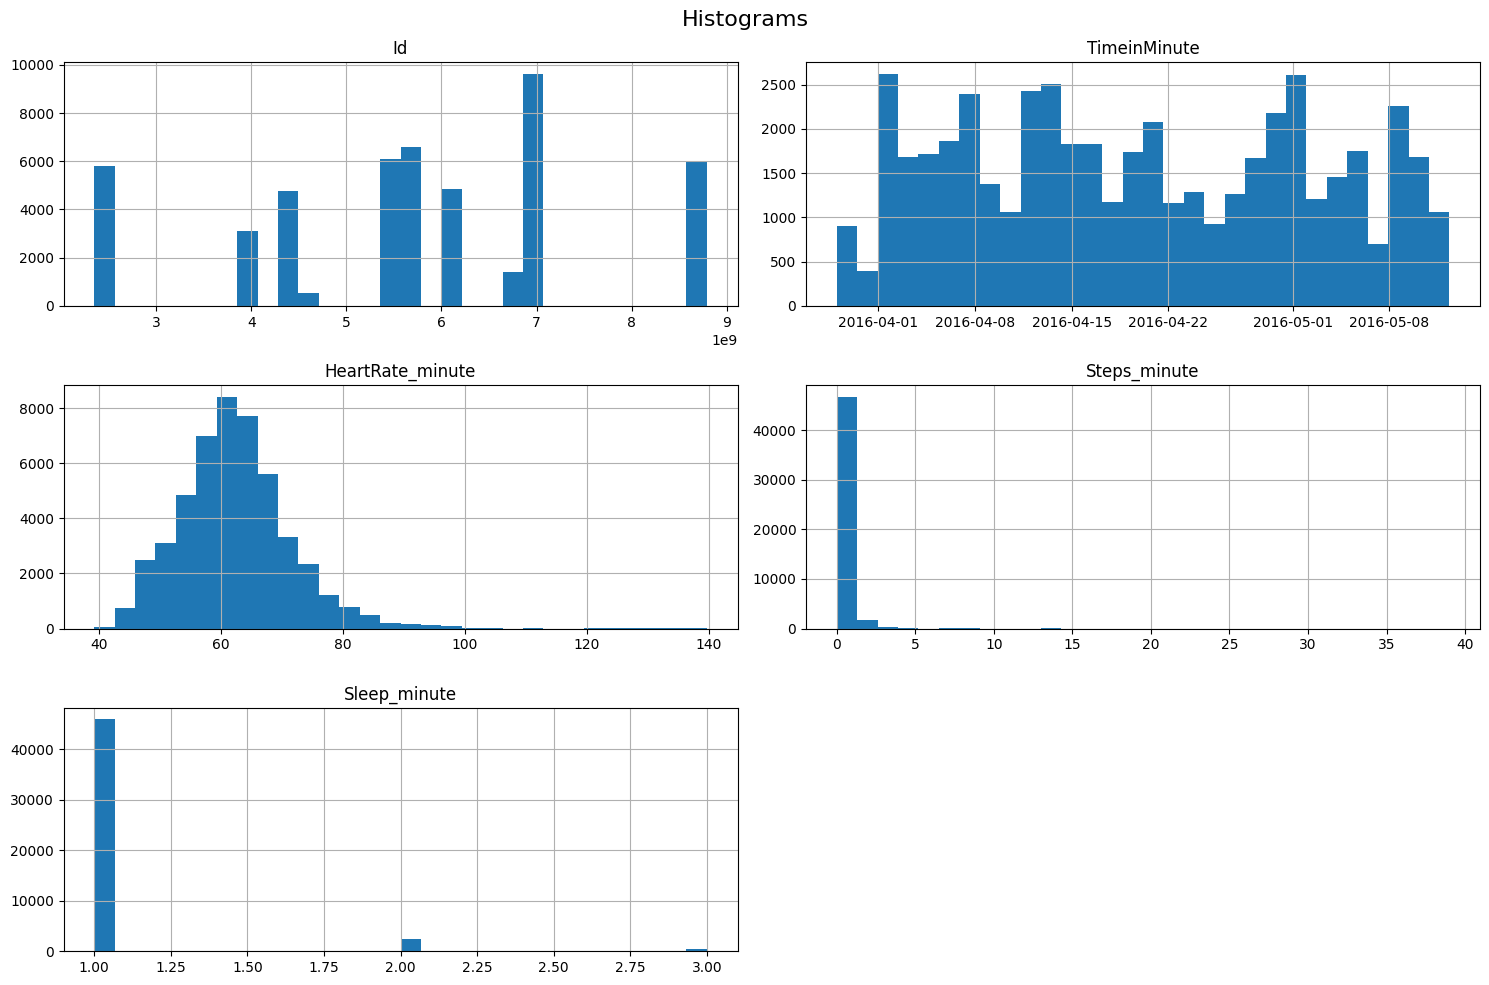

ValueError: Expected a 2-dimensional container but got <class 'pandas.core.series.Series'> instead. Pass a DataFrame containing a single row (i.e. single sample) or a single column (i.e. single feature) instead.

In [ ]:
# Neeed to understand why it's not working 

#EDA
# there are some columns that need to be normalised - for now I will scale all of them so they contribute the same to the model
# A second step would be to understand the distribution of each column alone and and do a pipeline

# scaler = StandardScaler()
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)

# # Need to retrasnform X_train in a dataframe

# X_train = pd.DataFrame(X_train, columns=X.columns)
# X_test = pd.DataFrame(X_test, columns=X.columns)

training_data.hist(bins=30, figsize=(15, 10))
plt.suptitle('Histograms', fontsize=16)
plt.tight_layout()
plt.show()

# Scaling the data

scaler = StandardScaler()
train_scaled = scaler.fit_transform(training_data["HeartRate_minute"])
test_transformed = scaler.transform(test_data["HeartRate_minute"])

# # Need to retrasnform X_train in a dataframe

# X_train = pd.DataFrame(X_train, columns=X.columns)
# X_test = pd.DataFrame(X_test, columns=X.columns)

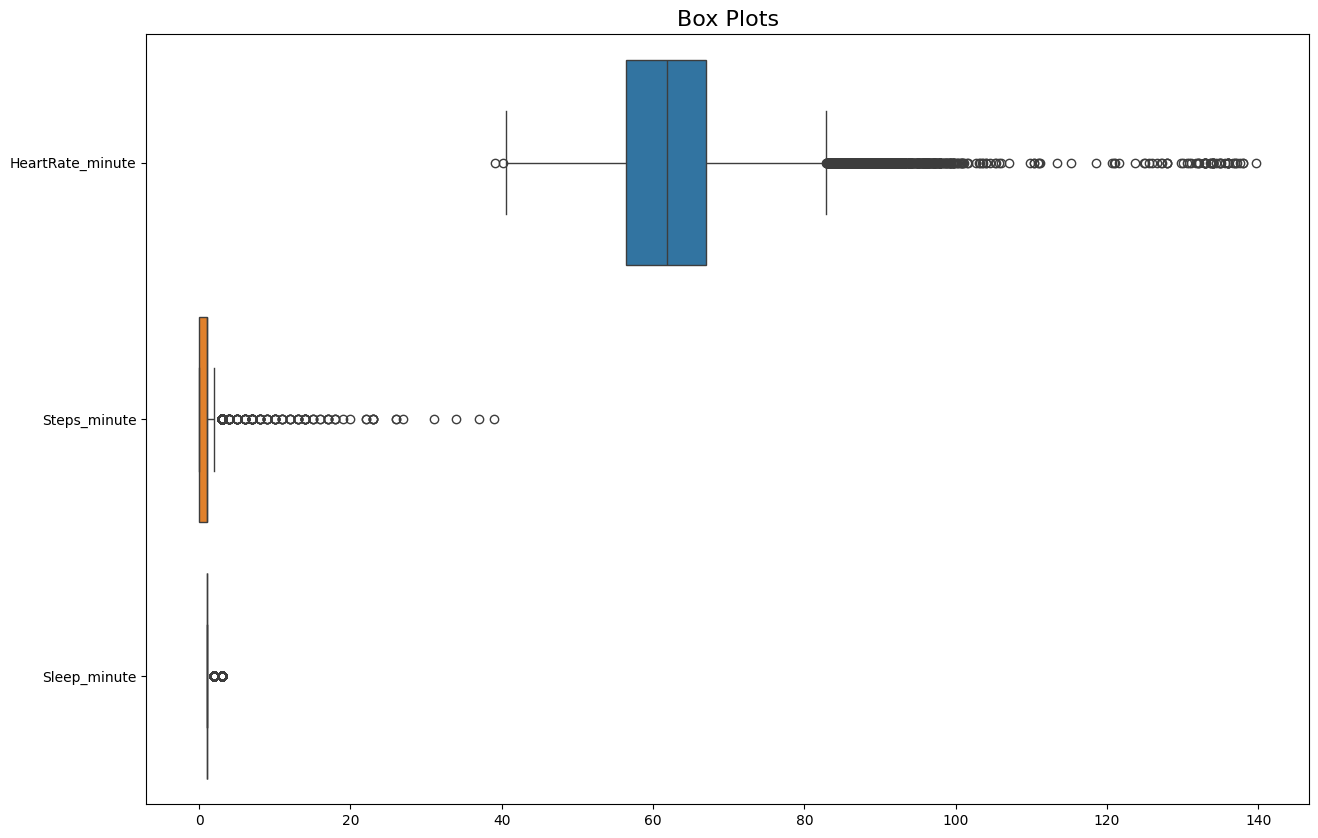

In [ ]:
data_distribution = training_data.drop(columns=["Id", "TimeinMinute"])
plt.figure(figsize=(15, 10))
sns.boxplot(data=data_distribution, orient='h')
plt.title('Box Plots', fontsize=16)
plt.show()